In [ ]:
!pip install gdown
!gdown 19jb_8kLw1aAAxbNBgY_3r4betXDxGtfo
!unzip examples.zip

Downloading...
From: https://drive.google.com/uc?id=19jb_8kLw1aAAxbNBgY_3r4betXDxGtfo
To: /content/examples.zip
100% 117k/117k [00:00<00:00, 24.9MB/s]
Archive:  examples.zip
   creating: examples/
  inflating: examples/AirPassengers.csv  
  inflating: examples/stock_px_2.csv  
  inflating: examples/Train.csv      


In [ ]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
np.random.seed(12345)
import matplotlib.pyplot as plt
plt.rc('figure', figsize=(10, 6))
np.set_printoptions(precision=4, suppress=True)

In [ ]:
!pip install statsmodels scipy

## Moving Window Functions

In [ ]:
close_px_all = pd.read_csv('examples/stock_px_2.csv',
                           parse_dates=True, index_col=0)
close_px = close_px_all[['AAPL', 'MSFT', 'XOM']]
close_px = close_px.resample('B').ffill()

<Axes: >

<Axes: >

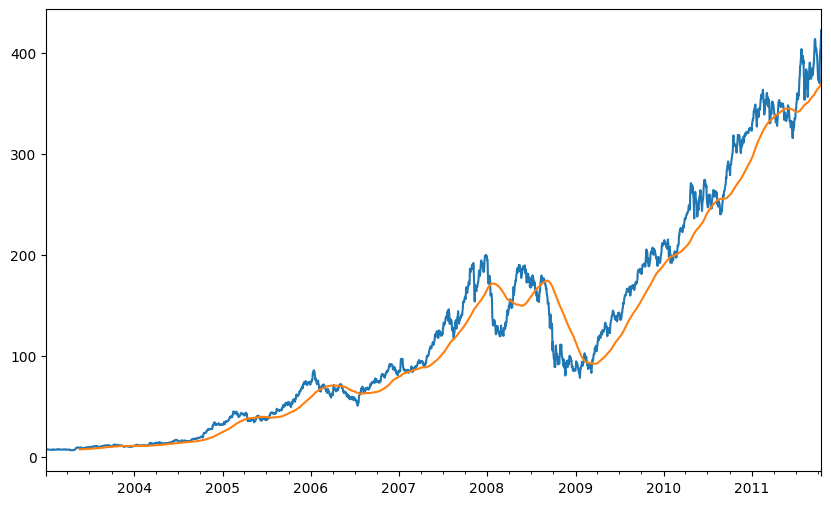

In [ ]:
close_px.AAPL.plot()
close_px.AAPL.rolling(100).mean().plot()

,AAPL
2003-01-09,NaN
2003-01-10,NaN
2003-01-13,NaN
2003-01-14,NaN
2003-01-15,7.355000
2003-01-16,7.350909
2003-01-17,7.325833


<Axes: >

<Axes: >

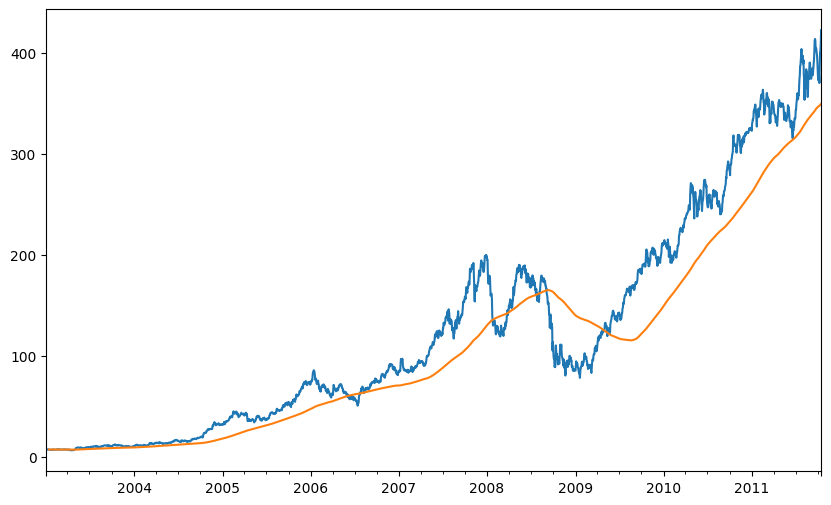

In [ ]:
appl_std250 = close_px.AAPL.rolling(250, min_periods=10).mean()
appl_std250[5:12]
close_px.AAPL.plot()
appl_std250.plot()

,AAPL
2003-01-09,NaN
2003-01-10,NaN
2003-01-13,NaN
2003-01-14,NaN
2003-01-15,NaN
2003-01-16,0.074760
2003-01-17,0.112368


<Axes: >

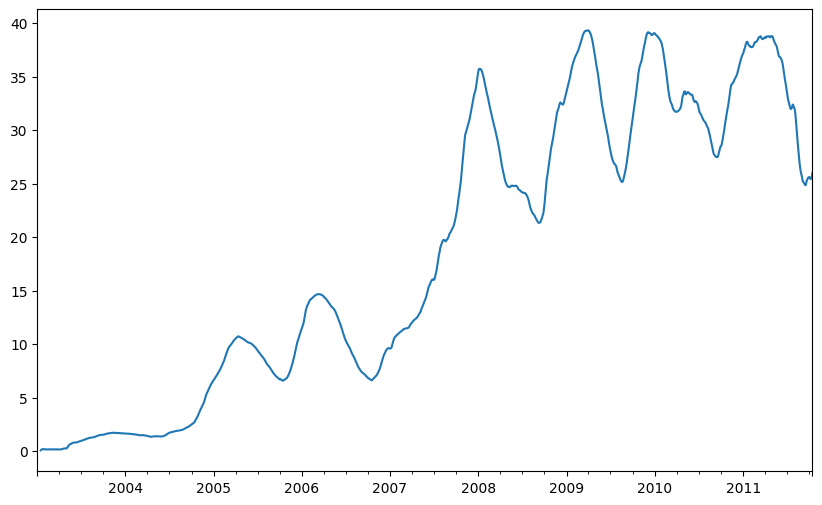

In [ ]:
appl_std250 = close_px.AAPL.rolling(250, min_periods=11).std()
appl_std250[5:12]
appl_std250.plot()

<Axes: >

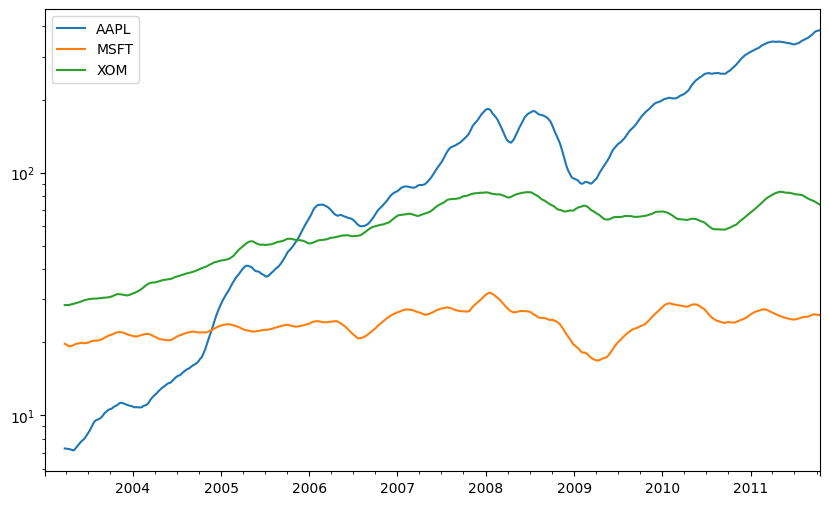

In [ ]:
close_px.rolling(60).mean().plot(logy=True)

,AAPL,MSFT,XOM
2003-01-02,7.400000,21.110000,29.220000
2003-01-03,7.425000,21.125000,29.230000
2003-01-06,7.433333,21.256667,29.473333
2003-01-07,7.432500,21.425000,29.342500
2003-01-08,7.402000,21.402000,29.240000
...,...,...,...
2011-10-10,389.351429,25.602143,72.527857
2011-10-11,388.505000,25.674286,72.835000
2011-10-12,388.531429,25.810000,73.400714
2011-10-13,388.826429,25.961429,73.905000


<Axes: >

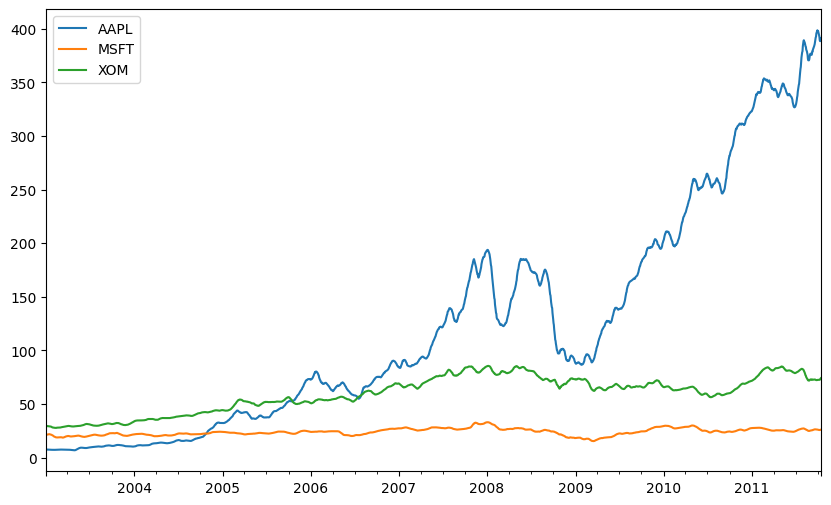

In [ ]:
close_px.rolling('20D').mean()
close_px.rolling('20D').mean().plot()

### Exponentially Weighted Functions

<Axes: >

<Axes: >

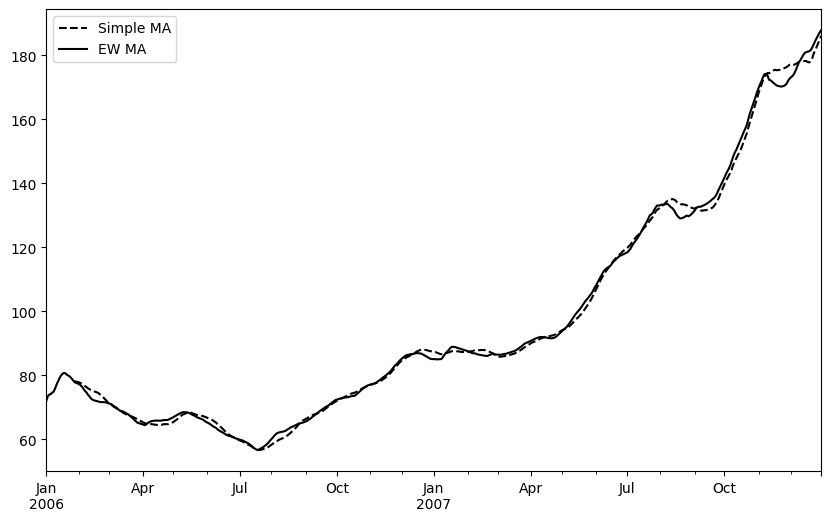

In [ ]:
aapl_px = close_px.AAPL['2006':'2007']
ma60 = aapl_px.rolling(30, min_periods=20).mean()
ewma60 = aapl_px.ewm(span=30).mean()
ma60.plot(style='k--', label='Simple MA')
ewma60.plot(style='k-', label='EW MA')
plt.legend()
#https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.ewm.html

## Time Series Imputation

In [ ]:
df = pd.DataFrame({'date': pd.date_range(start='2013-01-01', periods=10, freq='H'), 'value': range(10)})
df.loc[2:3, 'value'] = np.nan
df.loc[6, 'value'] = np.nan
df
df['value'].interpolate(method='linear', inplace=True)
df

,date,value
0,2013-01-01 00:00:00,0.0
1,2013-01-01 01:00:00,1.0
2,2013-01-01 02:00:00,NaN
3,2013-01-01 03:00:00,NaN
4,2013-01-01 04:00:00,4.0
5,2013-01-01 05:00:00,5.0
6,2013-01-01 06:00:00,NaN
7,2013-01-01 07:00:00,7.0
8,2013-01-01 08:00:00,8.0
9,2013-01-01 09:00:00,9.0


,date,value
0,2013-01-01 00:00:00,0.0
1,2013-01-01 01:00:00,1.0
2,2013-01-01 02:00:00,2.0
3,2013-01-01 03:00:00,3.0
4,2013-01-01 04:00:00,4.0
5,2013-01-01 05:00:00,5.0
6,2013-01-01 06:00:00,6.0
7,2013-01-01 07:00:00,7.0
8,2013-01-01 08:00:00,8.0
9,2013-01-01 09:00:00,9.0


In [ ]:
frame = pd.DataFrame({'Humidity':np.arange(50,64)})
frame.loc[[3,7,10,11],'Humidity'] = np.nan
frame
frame.Humidity.fillna(frame.Humidity.rolling(4,min_periods=1).mean())

,Humidity
0,50.0
1,51.0
2,52.0
3,NaN
4,54.0
5,55.0
6,56.0
7,NaN
8,58.0
9,59.0


,Humidity
0,50.0
1,51.0
2,52.0
3,51.0
4,54.0
5,55.0
6,56.0
7,55.0
8,58.0
9,59.0



# Time Series Forecasting

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6
data = pd.read_csv('examples/AirPassengers.csv')
print(data.head())
print('\n Data Types:')
print(data.dtypes)

     Month  #Passengers
0  1949-01          112
1  1949-02          118
2  1949-03          132
3  1949-04          129
4  1949-05          121

 Data Types:
Month          object
#Passengers     int64
dtype: object


In [ ]:
#dateparse = lambda dates: pd.datetime.strptime(dates, '%Y-%m')
from datetime import datetime
dateparse = lambda dates: datetime.strptime(dates, '%Y-%m')
data = pd.read_csv('examples/AirPassengers.csv', parse_dates=['Month'], index_col='Month',date_parser=dateparse)
print(data.head())

            #Passengers
Month                  
1949-01-01          112
1949-02-01          118
1949-03-01          132
1949-04-01          129
1949-05-01          121


In [ ]:
data.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq=None)

In [ ]:
ts = data['#Passengers']
ts.head(10)

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
1949-06-01,135
1949-07-01,148
1949-08-01,148
1949-09-01,136


In [ ]:
#1. Specific the index as a string constant:
ts['1949-01-01']

#2. Import the datetime library and use 'datetime' function:
from datetime import datetime
ts[datetime(1949,1,1)]

np.int64(112)

np.int64(112)

In [ ]:
#1. Specify the entire range:
ts['1949-01-01':'1949-05-01']

#2. Use ':' if one of the indices is at ends:
ts[:'1949-05-01']

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [ ]:
ts['1949']

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
1949-06-01,135
1949-07-01,148
1949-08-01,148
1949-09-01,136


# How to Check Stationarity of a Time Series?

we can assume the series to be stationary if it has constant statistical properties over time, ie. the following:

1. constant mean

2. constant variance

3. an autocovariance that does not depend on time.

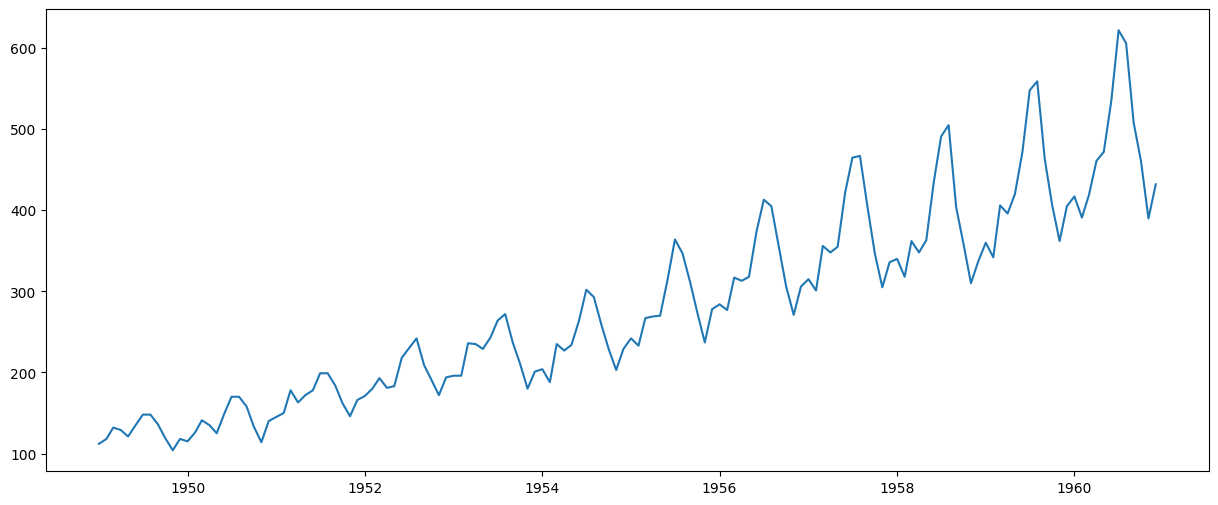

In [ ]:
plt.plot(ts)

we can check stationarity using the following:

Plotting Rolling Statistics: We can plot the moving average or moving variance and see if it varies with time. By moving average/variance I mean that at any instant ‘t’, we’ll take the average/variance of the last year, i.e. last 12 months. But again this is more of a visual technique.

Dickey-Fuller Test: This is one of the statistical tests for checking stationarity. Here the null hypothesis is that the TS is non-stationary. The test results comprise of a Test Statistic and some Critical Values for difference confidence levels. If the ‘Test Statistic’ is less than the ‘Critical Value’, we can reject the null hypothesis and say that the series is stationary.

In [ ]:
from statsmodels.tsa.stattools import adfuller
def test_stationarity(timeseries):

    #Determing rolling statistics
    rolmean = timeseries.rolling(12,min_periods=0).mean()
    rolstd = timeseries.rolling(12,min_periods=0).std()

    #Plot rolling statistics:
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)

    #Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

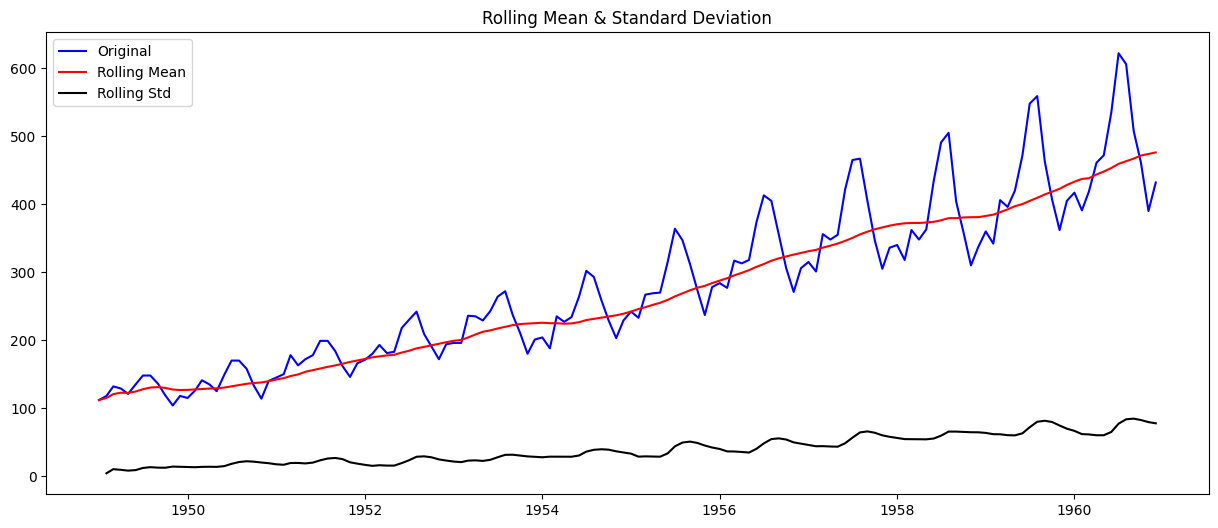

Results of Dickey-Fuller Test:
Test Statistic                   0.815369
p-value                          0.991880
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64


In [ ]:
test_stationarity(ts)

# How to make a Time Series Stationary?

There are 2 major reasons behind non-stationarity of a TS:
    
1. Trend – varying mean over time. For eg, in this case we saw that on average, the number of passengers was growing over time.

2. Seasonality – variations at specific time-frames. eg people might have a tendency to buy cars in a particular month because of pay increment or festivals.

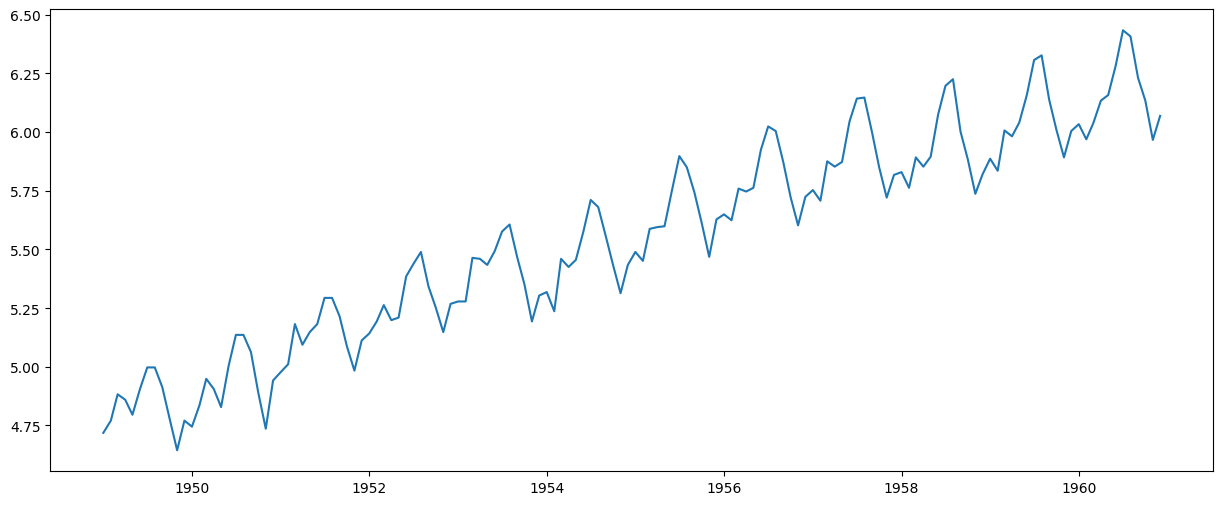

In [ ]:
#Estimating & Eliminating Trend
#we can apply transformation which penalize higher values more than smaller values.
#These can be taking a log, square root, cube root, etc. Lets take a log transform here for simplicity:
ts_log = np.log(ts)
plt.plot(ts_log)

we can use some techniques to estimate or model this trend and then remove it from the series. There can be many ways of doing it and some of most commonly used are:

1. Aggregation – taking average for a time period like monthly/weekly averages

2. Smoothing – taking rolling averages

3. Polynomial Fitting – fit a regression model

I will discuss smoothing here and you should try other techniques as well which might work out for other problems. Smoothing refers to taking rolling estimates, i.e. considering the past few instances.

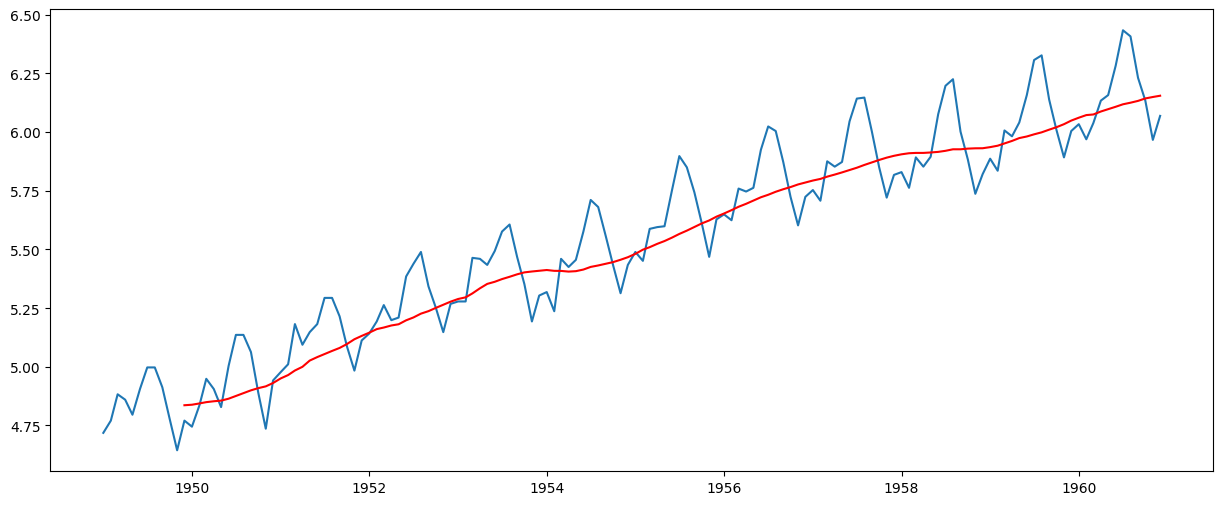

In [ ]:
#Moving average
moving_avg = ts_log.rolling(12).mean()
plt.plot(ts_log)
plt.plot(moving_avg, color='red')

,#Passengers
Month,
1949-01-01,NaN
1949-02-01,NaN
1949-03-01,NaN
1949-04-01,NaN
1949-05-01,NaN
1949-06-01,NaN
1949-07-01,NaN
1949-08-01,NaN
1949-09-01,NaN


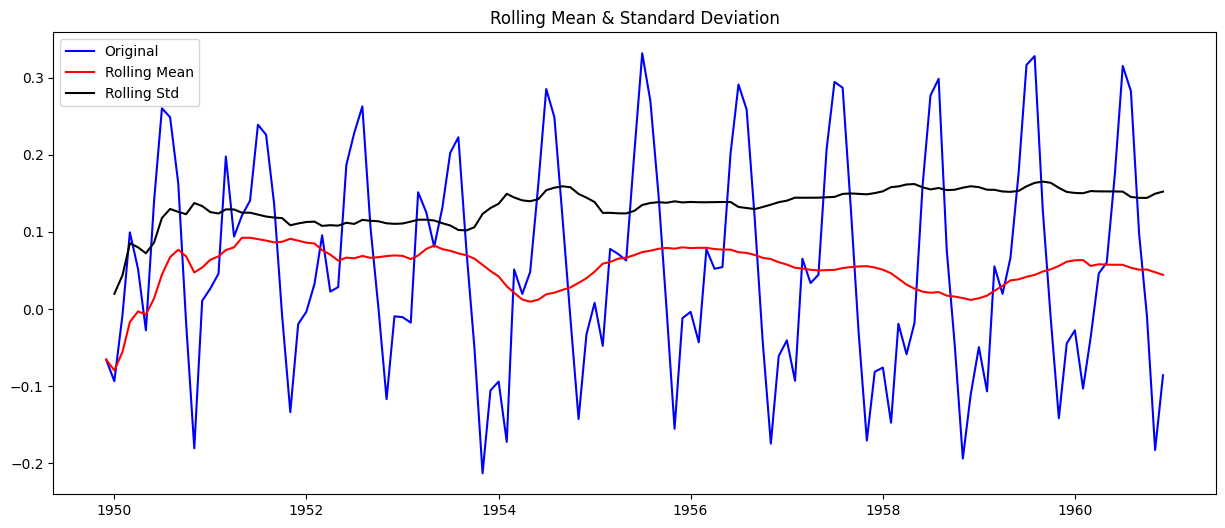

Results of Dickey-Fuller Test:
Test Statistic                  -3.162908
p-value                          0.022235
#Lags Used                      13.000000
Number of Observations Used    119.000000
Critical Value (1%)             -3.486535
Critical Value (5%)             -2.886151
Critical Value (10%)            -2.579896
dtype: float64


In [ ]:
#The red line shows the rolling mean. Lets subtract this from the original series.
#Note that since we are taking average of last 12 values, rolling mean is not defined for first 11 values.
ts_log_moving_avg_diff = ts_log - moving_avg
ts_log_moving_avg_diff.head(12)
ts_log_moving_avg_diff.dropna(inplace=True)
test_stationarity(ts_log_moving_avg_diff)

This looks like a much better series. The rolling values appear to be varying slightly but there is no specific trend. Also, the test statistic is smaller than the 5% critical values so we can say with 95% confidence that this is a stationary series.

However, a drawback in this particular approach is that the time-period has to be strictly defined. In this case we can take yearly averages but in complex situations like forecasting a stock price, its difficult to come up with a number. So we take a ‘weighted moving average’ where more recent values are given a higher weight. There can be many technique for assigning weights. A popular one is exponentially weighted moving average where weights are assigned to all the previous values with a decay factor.

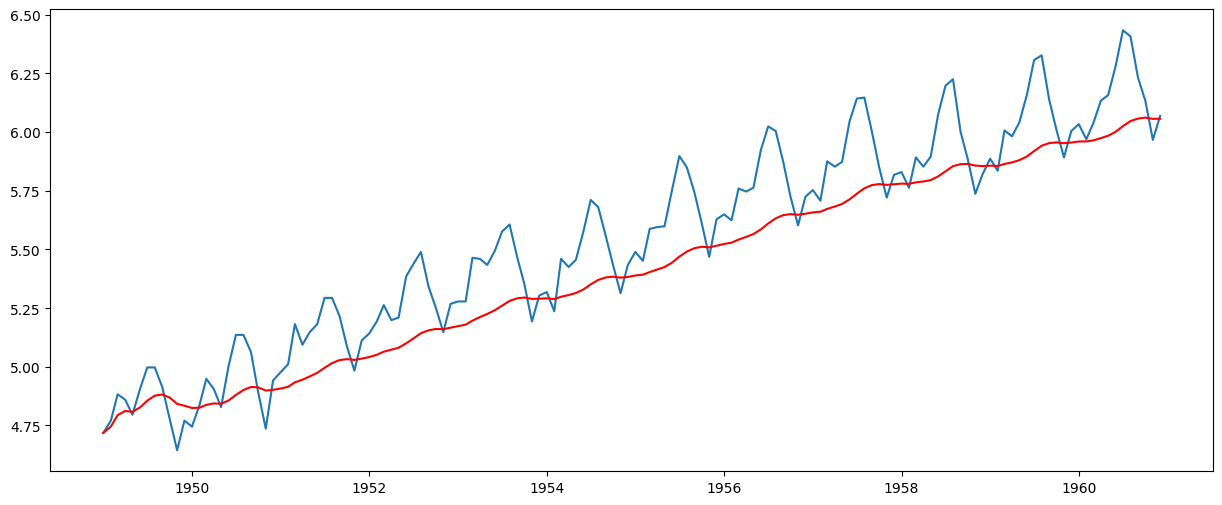

In [ ]:
expwighted_avg = ts_log.ewm(halflife=12).mean()
plt.plot(ts_log)
plt.plot(expwighted_avg, color='red')

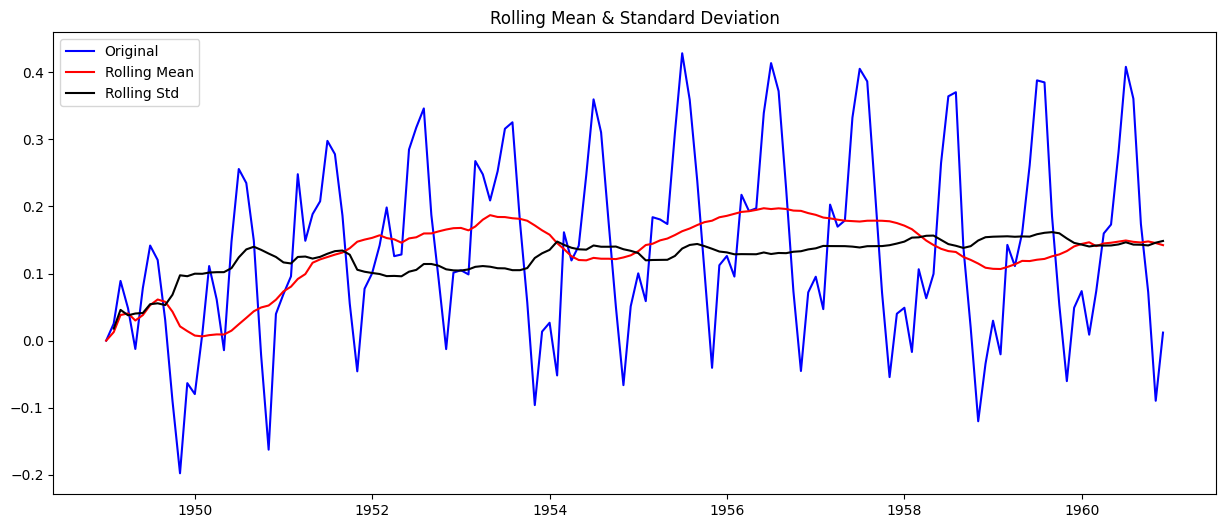

Results of Dickey-Fuller Test:
Test Statistic                  -3.601262
p-value                          0.005737
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64


In [ ]:
ts_log_ewma_diff = ts_log - expwighted_avg
test_stationarity(ts_log_ewma_diff)

This TS has even lesser variations in mean and standard deviation in magnitude. Also, the test statistic is smaller than the 1% critical value, which is better than the previous case. Note that in this case there can be no missing values as all values from starting are given weights. So it’ll work even with no previous values.

# Eliminating Trend and Seasonality

The simple trend reduction techniques discussed before don’t work in all cases, particularly the ones with high seasonality. Lets discuss two ways of removing trend and seasonality:

1. Differencing – taking the difference with a particular time lag

2. Decomposition – modeling both trend and seasonality and removing them from the model.

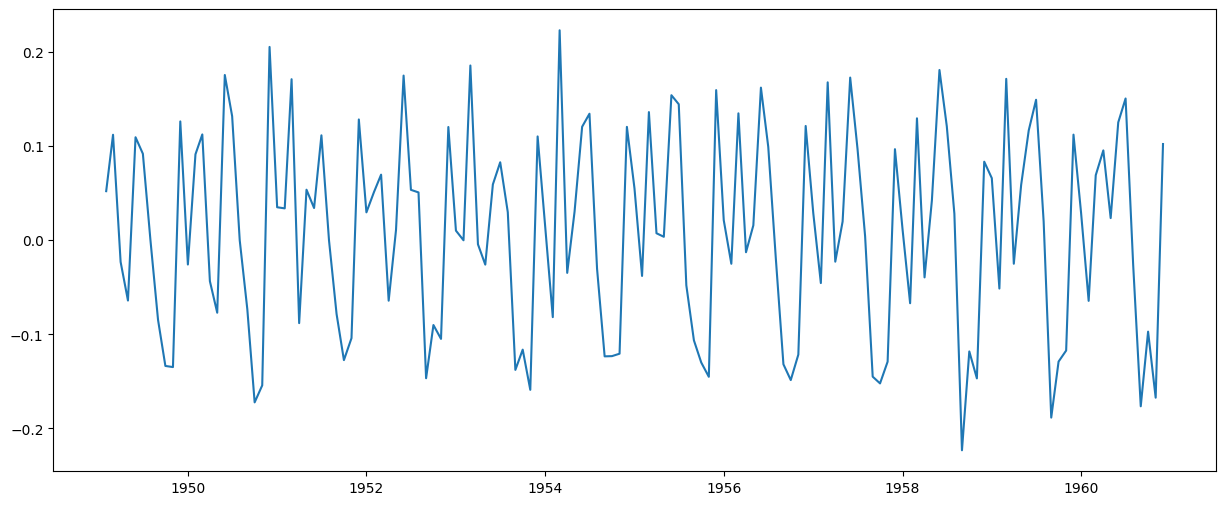

In [ ]:
#differencing
ts_log_diff = ts_log - ts_log.shift()
plt.plot(ts_log_diff)

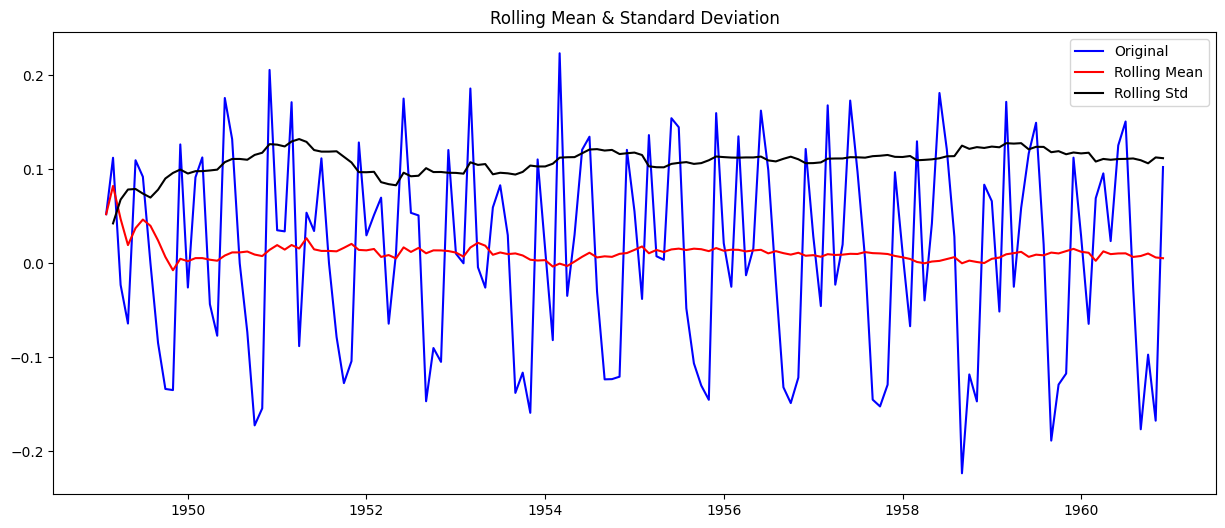

Results of Dickey-Fuller Test:
Test Statistic                  -2.717131
p-value                          0.071121
#Lags Used                      14.000000
Number of Observations Used    128.000000
Critical Value (1%)             -3.482501
Critical Value (5%)             -2.884398
Critical Value (10%)            -2.578960
dtype: float64


In [ ]:
ts_log_diff.dropna(inplace=True)
test_stationarity(ts_log_diff)

<Axes: >

<Axes: >

<Axes: >

<Axes: >

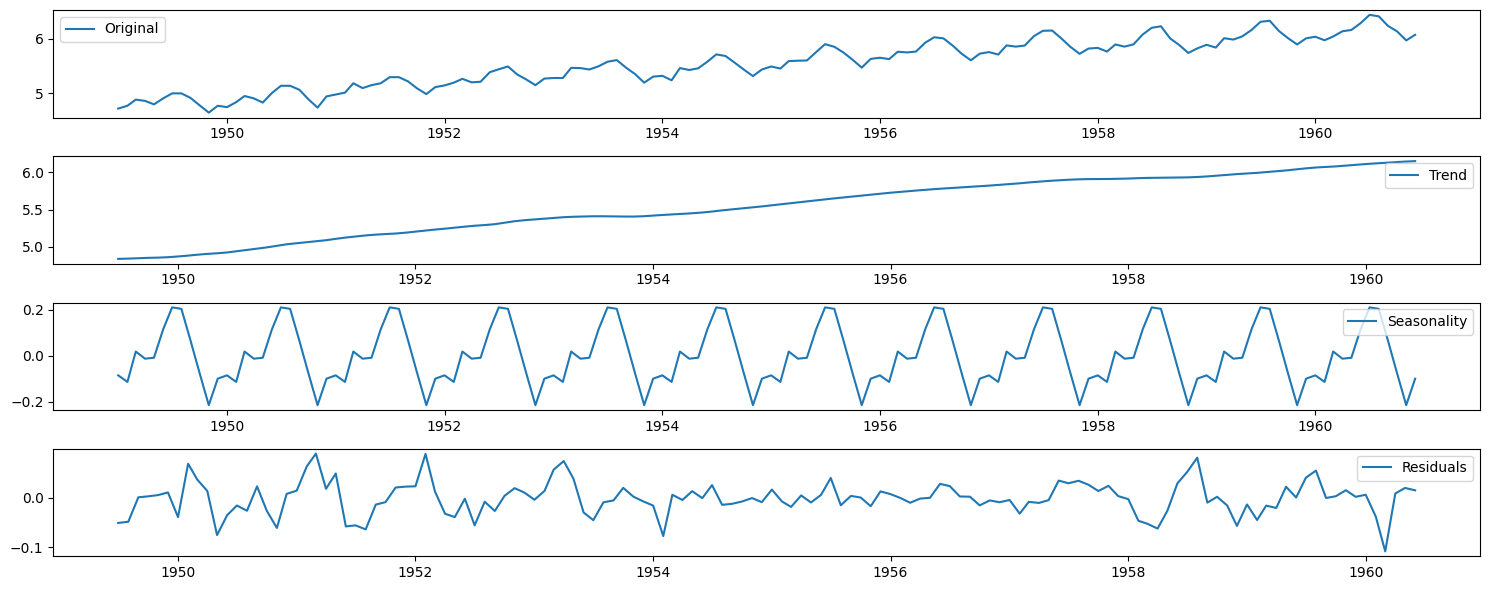

In [ ]:
#Decomposing
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(ts_log)

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

plt.subplot(411)
plt.plot(ts_log, label='Original')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(trend, label='Trend')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(seasonal,label='Seasonality')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(residual, label='Residuals')
plt.legend(loc='best')
plt.tight_layout()

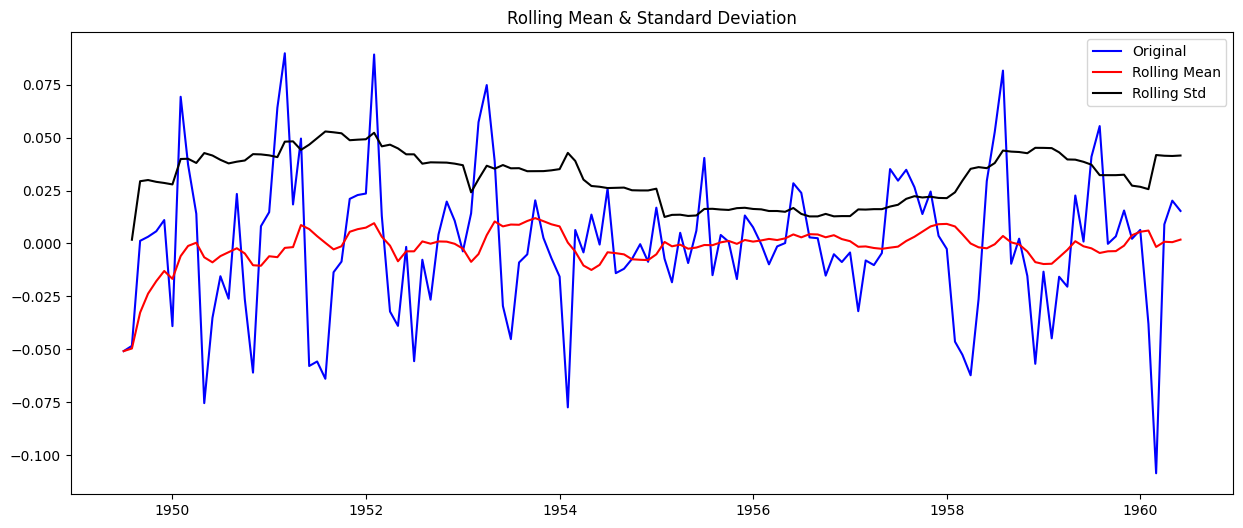

Results of Dickey-Fuller Test:
Test Statistic                -6.332387e+00
p-value                        2.885059e-08
#Lags Used                     9.000000e+00
Number of Observations Used    1.220000e+02
Critical Value (1%)           -3.485122e+00
Critical Value (5%)           -2.885538e+00
Critical Value (10%)          -2.579569e+00
dtype: float64


In [ ]:
ts_log_decompose = residual
ts_log_decompose.dropna(inplace=True)
test_stationarity(ts_log_decompose)

The Dickey-Fuller test statistic is significantly lower than the 1% critical value. So this TS is very close to stationary. You can try advanced decomposition techniques as well which can generate better results. Also, you should note that converting the residuals into original values for future data in not very intuitive in this case.

# Forecasting a Time Series

An importance concern here is how to determine the value of ‘p’ and ‘q’. We use two plots to determine these numbers. Lets discuss them first.

Autocorrelation Function (ACF): It is a measure of the correlation between the the TS with a lagged version of itself. For instance at lag 5, ACF would compare series at time instant ‘t1’…’t2’ with series at instant ‘t1-5’…’t2-5’ (t1-5 and t2 being end points).

Partial Autocorrelation Function (PACF): This measures the correlation between the TS with a lagged version of itself but after eliminating the variations already explained by the intervening comparisons. Eg at lag 5, it will check the correlation but remove the effects already explained by lags 1 to 4.

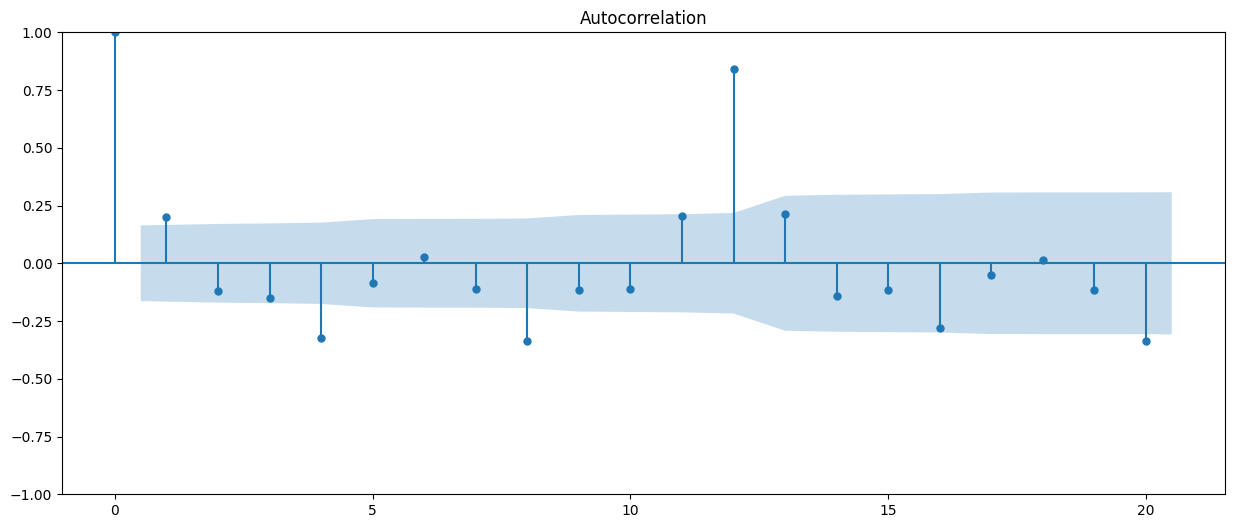

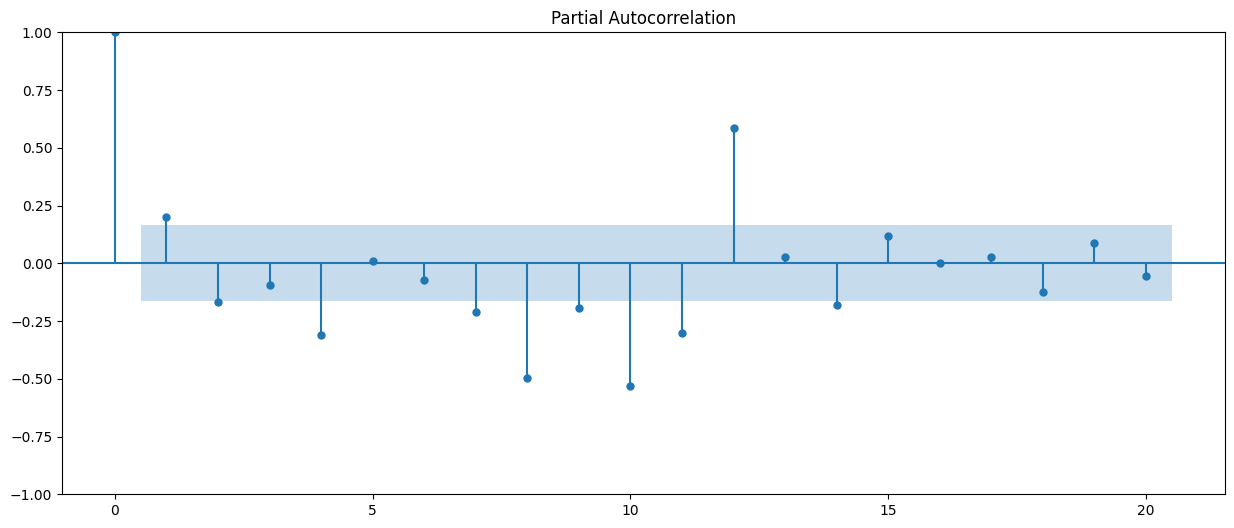

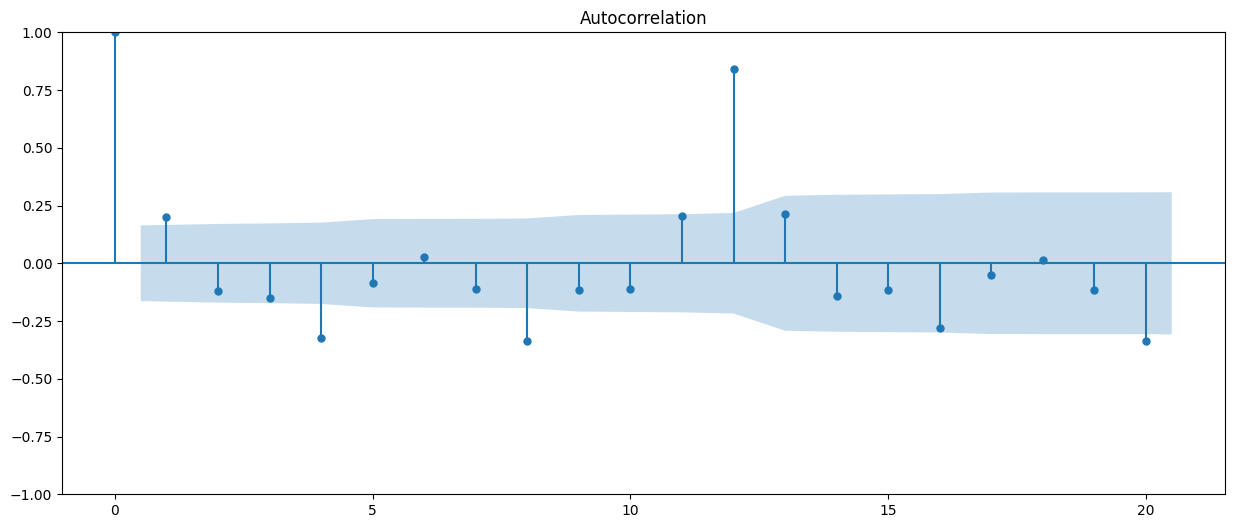

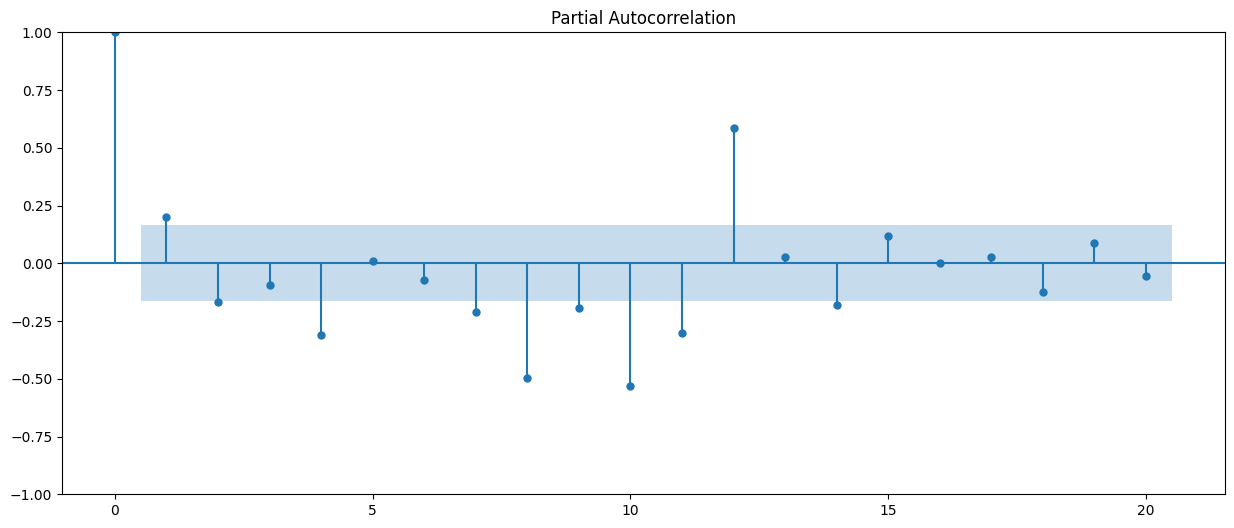

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(ts_log_diff,lags=20)
#plt.show()
plot_pacf(ts_log_diff,lags=20)
#plt.show()

<Axes: >

Text(0.5, 1.0, 'Autocorrelation Function')

<Axes: >

Text(0.5, 1.0, 'Partial Autocorrelation Function')

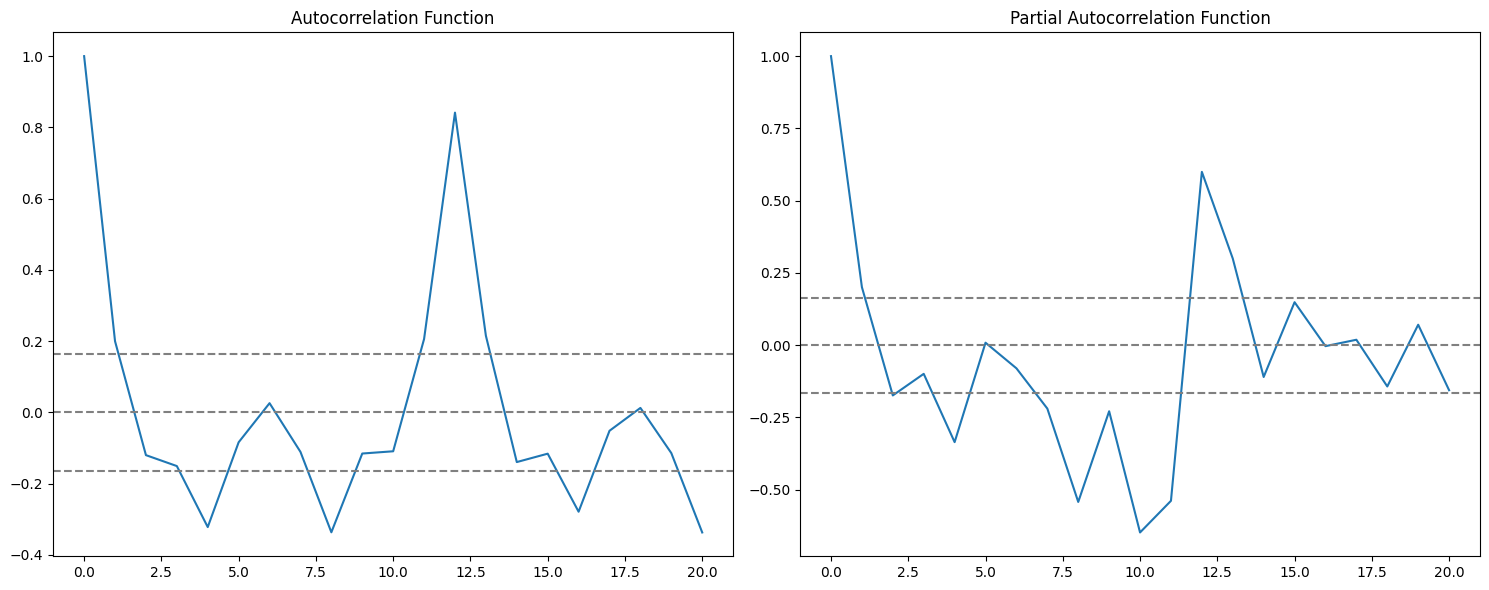

In [ ]:
#ACF and PACF plots:
from statsmodels.tsa.stattools import acf, pacf
lag_acf = acf(ts_log_diff, nlags=20)
lag_pacf = pacf(ts_log_diff, nlags=20, method='ols')
#Plot ACF:
plt.subplot(121)
plt.plot(lag_acf)
plt.axhline(y=0,linestyle='--',color='gray')
plt.axhline(y=-1.96/np.sqrt(len(ts_log_diff)),linestyle='--',color='gray')
plt.axhline(y=1.96/np.sqrt(len(ts_log_diff)),linestyle='--',color='gray')
plt.title('Autocorrelation Function')
#Plot PACF:
plt.subplot(122)
plt.plot(lag_pacf)
plt.axhline(y=0,linestyle='--',color='gray')
plt.axhline(y=-1.96/np.sqrt(len(ts_log_diff)),linestyle='--',color='gray')
plt.axhline(y=1.96/np.sqrt(len(ts_log_diff)),linestyle='--',color='gray')
plt.title('Partial Autocorrelation Function')
plt.tight_layout()

In this plot, the two dotted lines on either sides of 0 are the confidence interevals. These can be used to determine the ‘p’ and ‘q’ values as:

p – The lag value where the PACF chart crosses the upper confidence interval for the first time. If you notice closely, in this case p=2.

q – The lag value where the ACF chart crosses the upper confidence interval for the first time. If you notice closely, in this case q=2.

Now, lets make 3 different ARIMA models considering individual as well as combined effects. I will also print the RSS for each. Please note that here RSS is for the values of residuals and not actual series.

## Fit ARIMA(2,1,0)

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
model=ARIMA(ts_log,order=(2,1,0))
results=model.fit()
print(results.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:            #Passengers   No. Observations:                  144
Model:                 ARIMA(2, 1, 0)   Log Likelihood                 122.261
Date:                Fri, 31 Jul 2026   AIC                           -238.522
Time:                        18:15:00   BIC                           -229.633
Sample:                    01-01-1949   HQIC                          -234.910
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2414      0.101      2.381      0.017       0.043       0.440
ar.L2         -0.1667      0.100     -1.665      0.096      -0.363       0.030
sigma2         0.0106      0.002      6.020      0.0

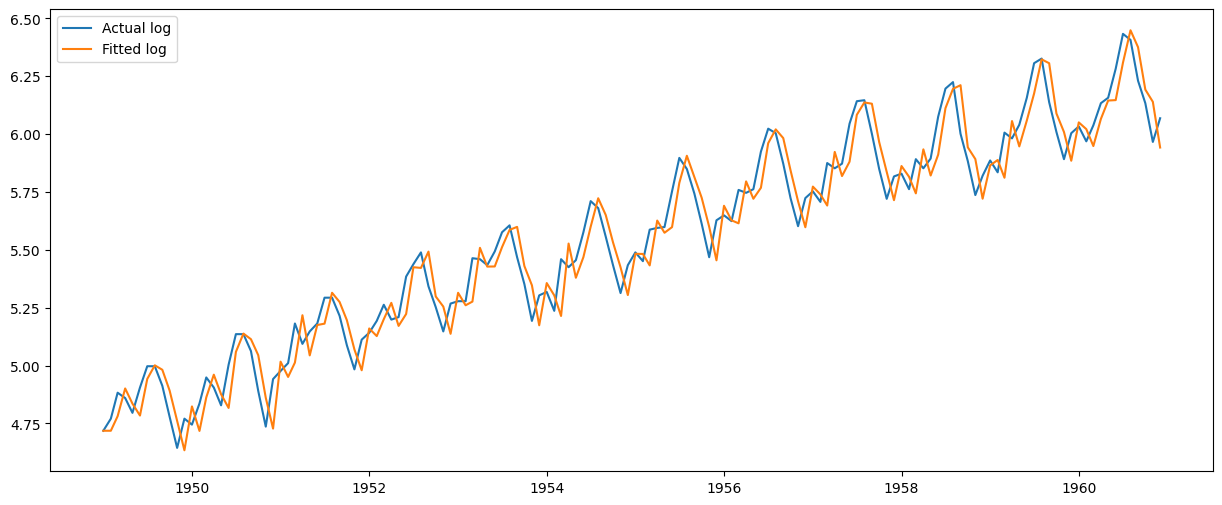

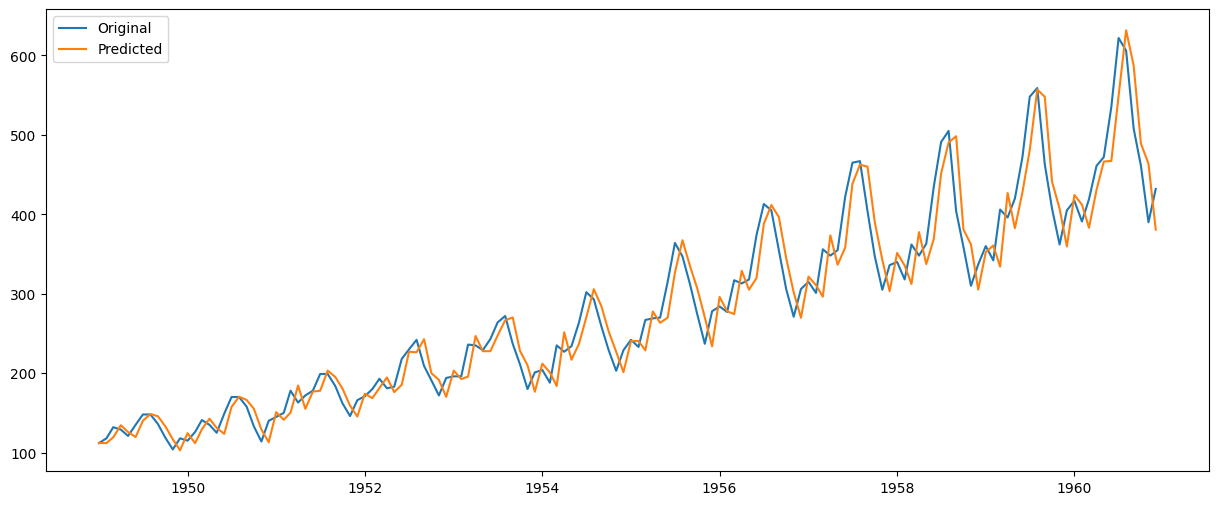

In [ ]:
fitted=results.fittedvalues
fitted[0]=ts_log[0]
plt.plot(ts_log,label='Actual log')
plt.plot(fitted,label='Fitted log')
plt.legend(); plt.show()

pred=np.exp(fitted)
plt.plot(ts,label='Original')
plt.plot(pred,label='Predicted')
plt.legend(); plt.show()

In [ ]:
fc=results.get_forecast(24)
forecast=np.exp(fc.predicted_mean)
forecast.head()

,predicted_mean
1961-01-01,455.314368
1961-02-01,453.333698
1961-03-01,448.906993
1961-04-01,448.170536
1961-05-01,448.726239


In [ ]:
print('RMSE=', np.sqrt(sum((pred-ts)**2)/len(ts)))

RMSE= 31.424523679742602


### fbprophet

https://www.geeksforgeeks.org/data-science/time-series-analysis-using-facebook-prophet/

The "Prophet Equation" fits trends, seasonality, and holidays. This is given by,

y(t) = g(t) + s(t) + h(t) + e(t)

here,

g(t) refers to trend (changes over a long period of time)

s(t) refers to seasonality (periodic or short-term changes)

h(t) refers to effects of holidays to the forecast

e(t) refers to the unconditional changes that is specific to a business or a person or a circumstance. It is also called the error term.

y(t) is the forecast.


Prophet provides us with two models: Logistic Growth Model, Piece-Wise Linear Model

By default, Prophet uses a piece-wise linear model, but it can be changed by specifying the model.

In [ ]:
!pip install prophet

In [ ]:
import pandas as pd
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot
data = pd.read_csv('examples/AirPassengers.csv')
df = pd.DataFrame()
df['ds'] = pd.to_datetime(data['Month'])
df['y'] = data['#Passengers']
df.head()

m = Prophet()
m.fit(df)

,ds,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future = m.make_future_dataframe(periods=12 * 5, freq='M')

In [ ]:
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower',
          'yhat_upper', 'trend',
          'trend_lower', 'trend_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper,trend,trend_lower,trend_upper
199,1965-07-31,723.847944,695.703509,753.978159,656.874778,650.147669,663.838843
200,1965-08-31,677.972723,649.506599,705.641013,660.006426,653.066437,667.186699
201,1965-09-30,640.723591,610.584591,672.958379,663.037053,655.924170,670.421775
202,1965-10-31,610.965209,581.334253,639.634522,666.168701,658.834742,673.822450
203,1965-11-30,640.594097,610.071898,669.686648,669.199329,661.727387,677.052532


Table ds is the time series data. yhat is the prediction, yhat_lower, and yhat_upper are the uncertainty levels (it basically means the prediction and actual values can vary within the bounds of the uncertainty levels). Next up we have a trend that shows the long-term growth, shrink, or stagnancy of the data, trend_lower, and trend_upper is the uncertainty levels.

The below image shows the basic prediction. The light blue is the uncertainty level(yhat_upper and yhat_lower), the dark blue is the prediction(yhat) and the black dots are the original data. We can see that the predicted data is very close to the actual data. In the last five years, there is no "actual" data, but looking at the performance of our model in years where data is available it is safe to say that the predictions are close to accurate.

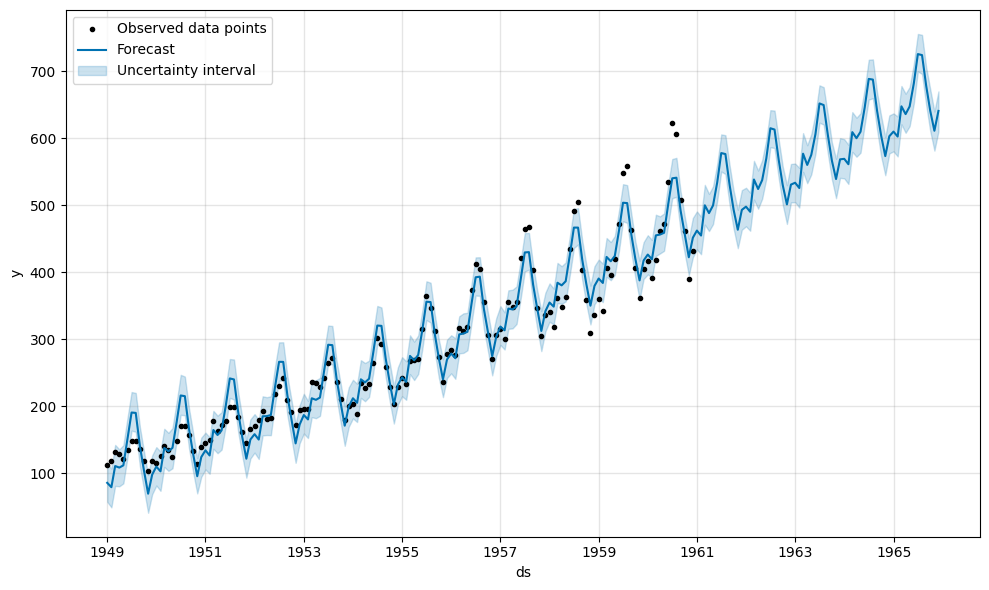

In [ ]:
fig1 = m.plot(forecast, include_legend=True)

The below images show the trends and seasonality (in a year) of the time series data. We can see there is an increasing trend, meaning the number of air passengers has increased over time. If we look at the seasonality graph, we can see that June and July is the time with the most passengers in a given year.

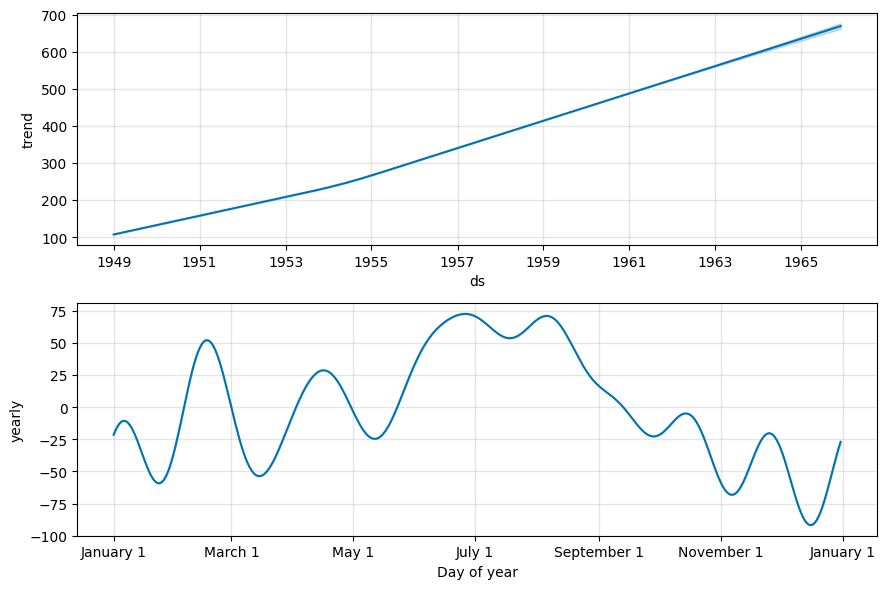

In [ ]:
fig2 = m.plot_components(forecast)

Add changepoints to indicate the time in rapid trend growths. The dotted red lines show the time when there was a rapid change in the trend of the passengers.

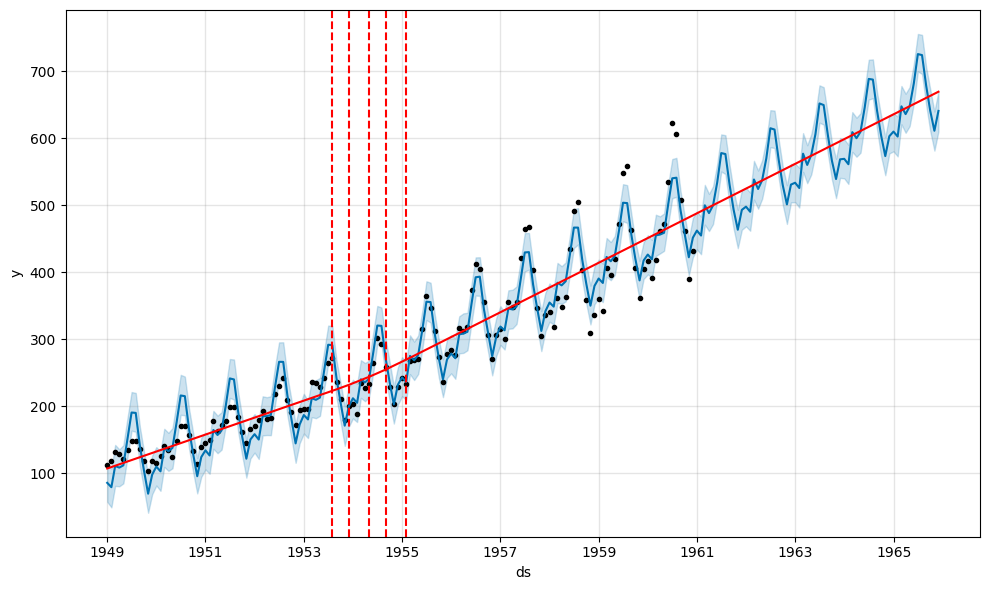

In [ ]:
fig = m.plot(forecast)
a = add_changepoints_to_plot(fig.gca(), m, forecast)

# More Methods for forecasting

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#Importing data
df = pd.read_csv('examples/Train.csv')
#Printing head
df.head()

#Subsetting the dataset
#Index 11856 marks the end of year 2013
df = pd.read_csv('examples/Train.csv', nrows = 11856)

#Creating train and test set
#Index 10392 marks the end of October 2013
train=df[0:10392]
test=df[10392:]

#Aggregating the dataset at daily level
df['Timestamp'] = pd.to_datetime(df['Datetime'], format='%d-%m-%Y %H:%M')
df = df.set_index('Timestamp')
df = df.resample('D').mean(numeric_only=True)

train['Timestamp'] = pd.to_datetime(train['Datetime'], format='%d-%m-%Y %H:%M')
train = train.set_index('Timestamp')
train = train.resample('D').mean(numeric_only=True)

test['Timestamp'] = pd.to_datetime(test['Datetime'], format='%d-%m-%Y %H:%M')
test = test.set_index('Timestamp')
test = test.resample('D').mean(numeric_only=True)

,ID,Datetime,Count
0,0,25-08-2012 00:00,8
1,1,25-08-2012 01:00,2
2,2,25-08-2012 02:00,6
3,3,25-08-2012 03:00,2
4,4,25-08-2012 04:00,2


<Axes: title={'center': 'Daily Ridership'}, xlabel='Timestamp'>

<Axes: title={'center': 'Daily Ridership'}, xlabel='Timestamp'>

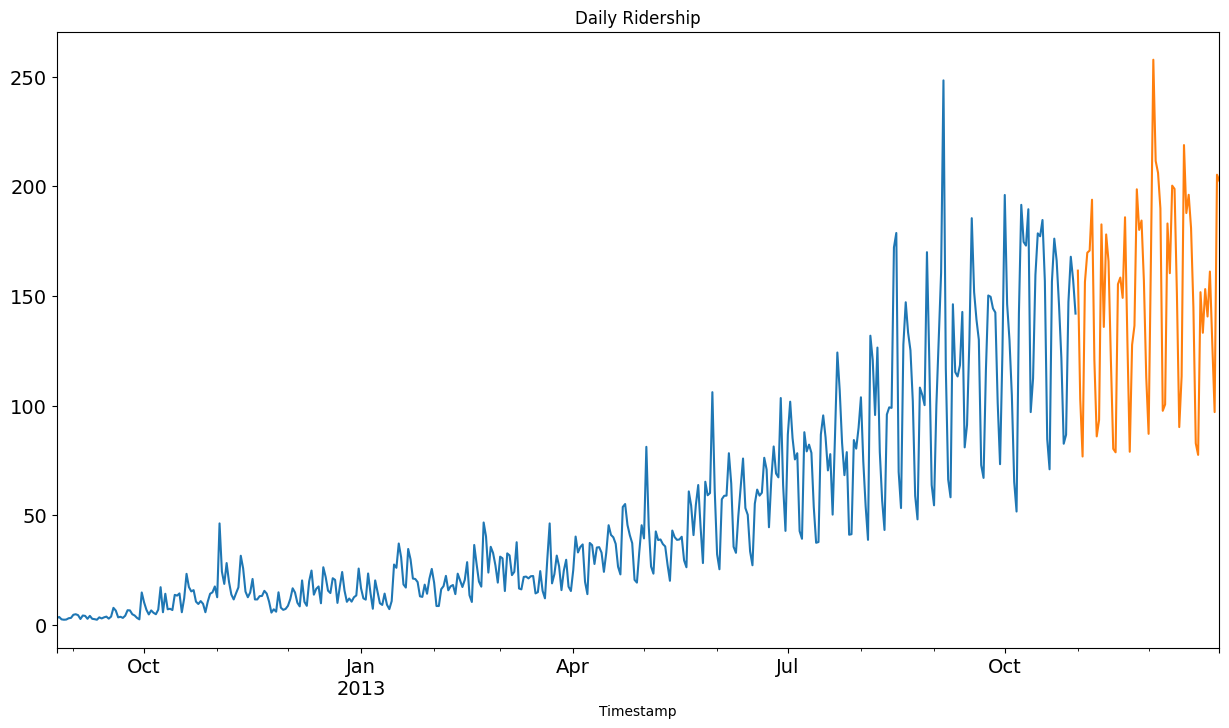

In [ ]:
#Plotting data
train.Count.plot(figsize=(15,8), title= 'Daily Ridership', fontsize=14)
test.Count.plot(figsize=(15,8), title= 'Daily Ridership', fontsize=14)
plt.show()

<Figure size 1200x800 with 0 Axes>

Text(0.5, 1.0, 'Naive Forecast')

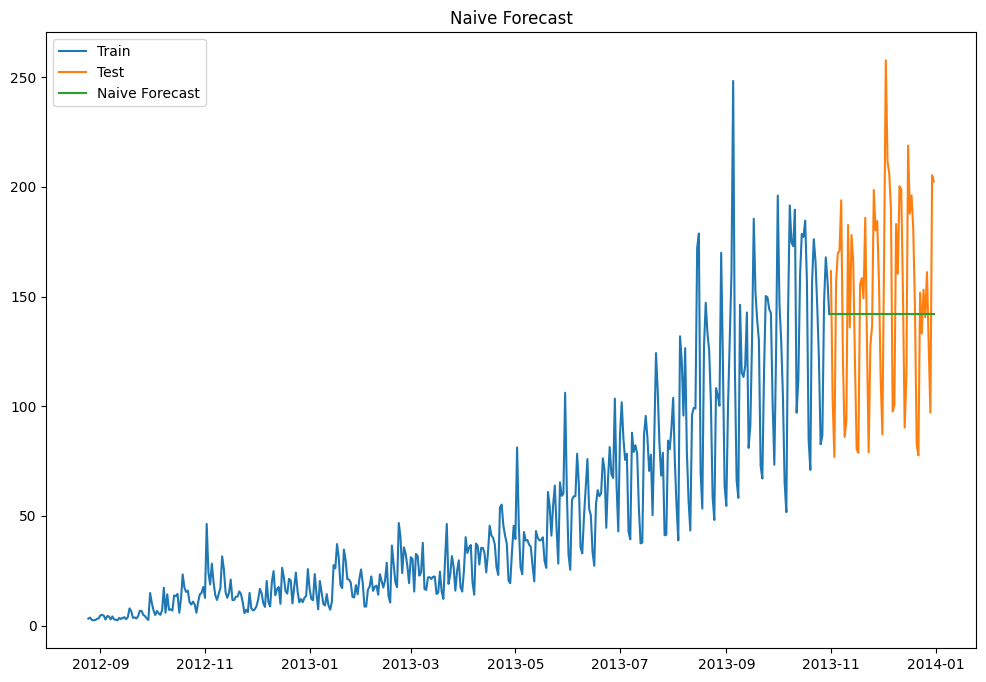

In [ ]:
#Naive approach to forecasting
#If we want to forecast the price for the next day,
#we can simply take the last day value and estimate the same value for the next day.
#i.e.next y = current y
dd= np.asarray(train.Count)
y_hat = test.copy()
y_hat['naive'] = dd[len(dd)-1]
plt.figure(figsize=(12,8))
plt.plot(train.index, train['Count'], label='Train')
plt.plot(test.index,test['Count'], label='Test')
plt.plot(y_hat.index,y_hat['naive'], label='Naive Forecast')
plt.legend(loc='best')
plt.title("Naive Forecast")
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error
from math import sqrt
rms = sqrt(mean_squared_error(test.Count, y_hat.naive))
print(rms)


43.91640614391676


<Figure size 1200x800 with 0 Axes>

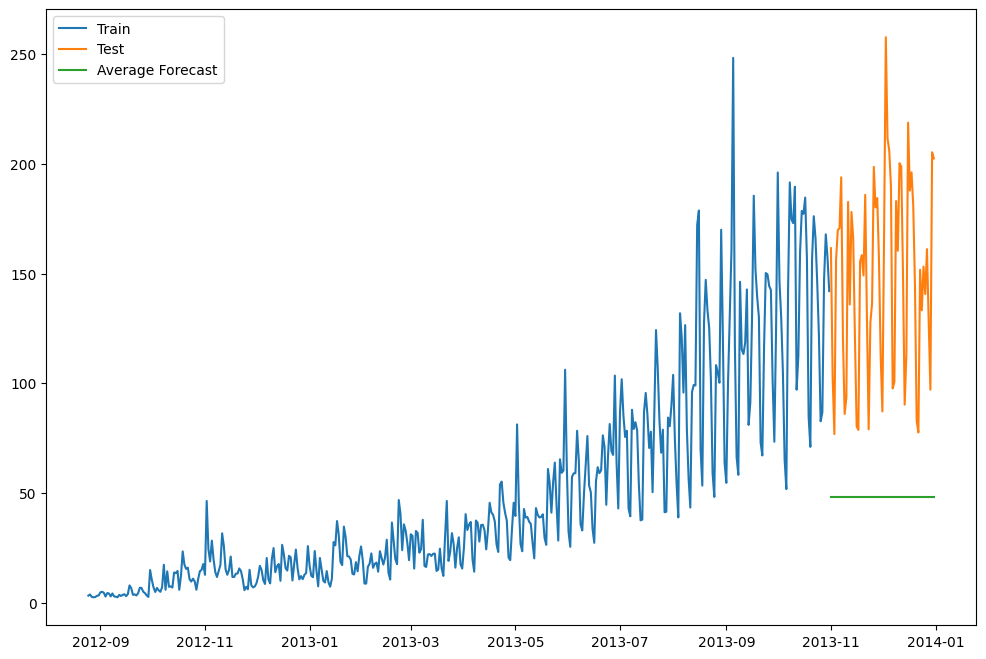

In [ ]:
#Simple Average
#We take all the values previously known, calculate the average and take it as the next value.
y_hat_avg = test.copy()
y_hat_avg['avg_forecast'] = train['Count'].mean()
plt.figure(figsize=(12,8))
plt.plot(train['Count'], label='Train')
plt.plot(test['Count'], label='Test')
plt.plot(y_hat_avg['avg_forecast'], label='Average Forecast')
plt.legend(loc='best')
plt.show()

<Figure size 1600x800 with 0 Axes>

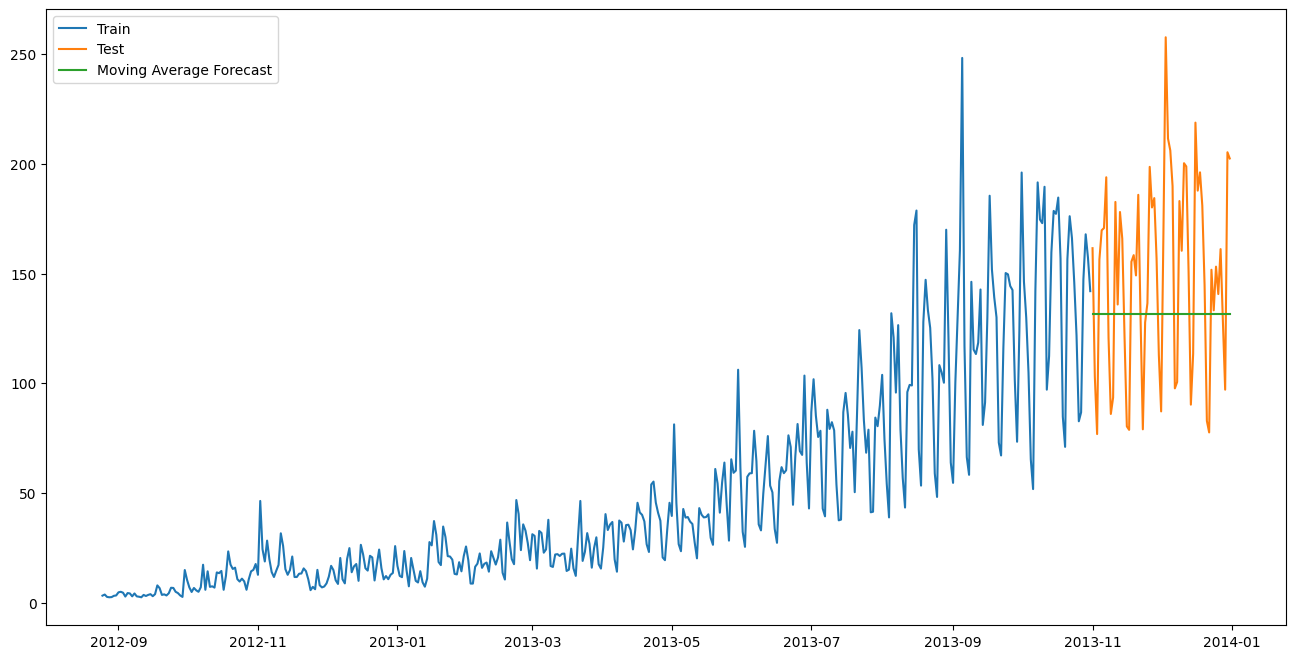

In [ ]:
#Moving Average
#Using a simple moving average model, we forecast the next value(s) in a
#time series based on the average of a fixed finite number ‘p’ of the previous values.
y_hat_avg = test.copy()
y_hat_avg['moving_avg_forecast'] = train['Count'].rolling(60).mean().iloc[-1]
plt.figure(figsize=(16,8))
plt.plot(train['Count'], label='Train')
plt.plot(test['Count'], label='Test')
plt.plot(y_hat_avg['moving_avg_forecast'], label='Moving Average Forecast')
plt.legend(loc='best')
plt.show()

In [ ]:
rms = sqrt(mean_squared_error(test.Count, y_hat_avg.moving_avg_forecast))
print(rms)

46.72840725106963


<Figure size 1600x800 with 0 Axes>

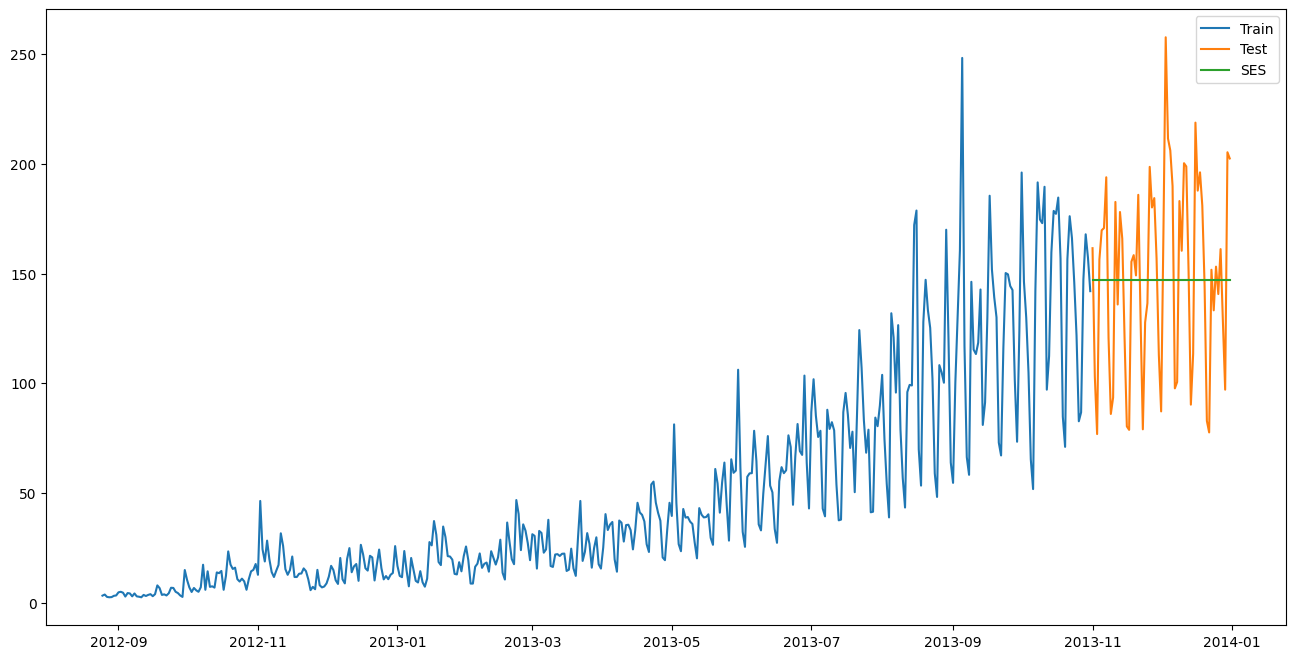

In [ ]:
#Method 4 – Simple Exponential Smoothing
#pip install statsmodels==0.9.0rc1

from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt
y_hat_avg = test.copy()
fit2 = SimpleExpSmoothing(np.asarray(train['Count'])).fit(smoothing_level=0.6,optimized=False)
y_hat_avg['SES'] = fit2.forecast(len(test))
plt.figure(figsize=(16,8))
plt.plot(train['Count'], label='Train')
plt.plot(test['Count'], label='Test')
plt.plot(y_hat_avg['SES'], label='SES')
plt.legend(loc='best')
plt.show()

In [ ]:
rms = sqrt(mean_squared_error(test.Count, y_hat_avg.SES))
print(rms)


43.357625225228155


#Method 5 – Holt’s Linear Trend method

Although each one of these methods can be applied to the trend as well.  E.g. the Naive method would assume that trend between last two points is going to stay the same, or we could average all slopes between all points to get an average trend, use a moving trend average or apply exponential smoothing.

But we need a method that can map the trend accurately without any assumptions. Such a method that takes into account the trend of the dataset is called Holt’s Linear Trend method.

Each Time series dataset can be decomposed into it’s componenets which are Trend, Seasonality and Residual. Any dataset that follows a trend can use Holt’s linear trend method for forecasting.

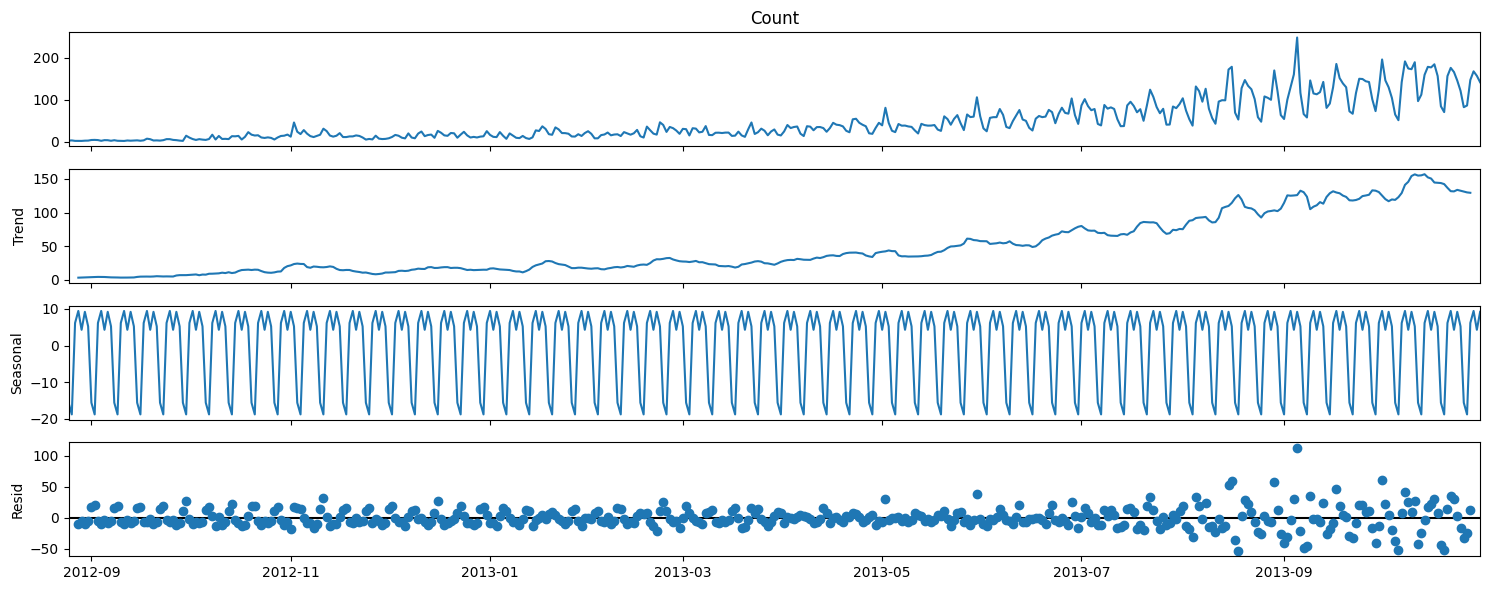

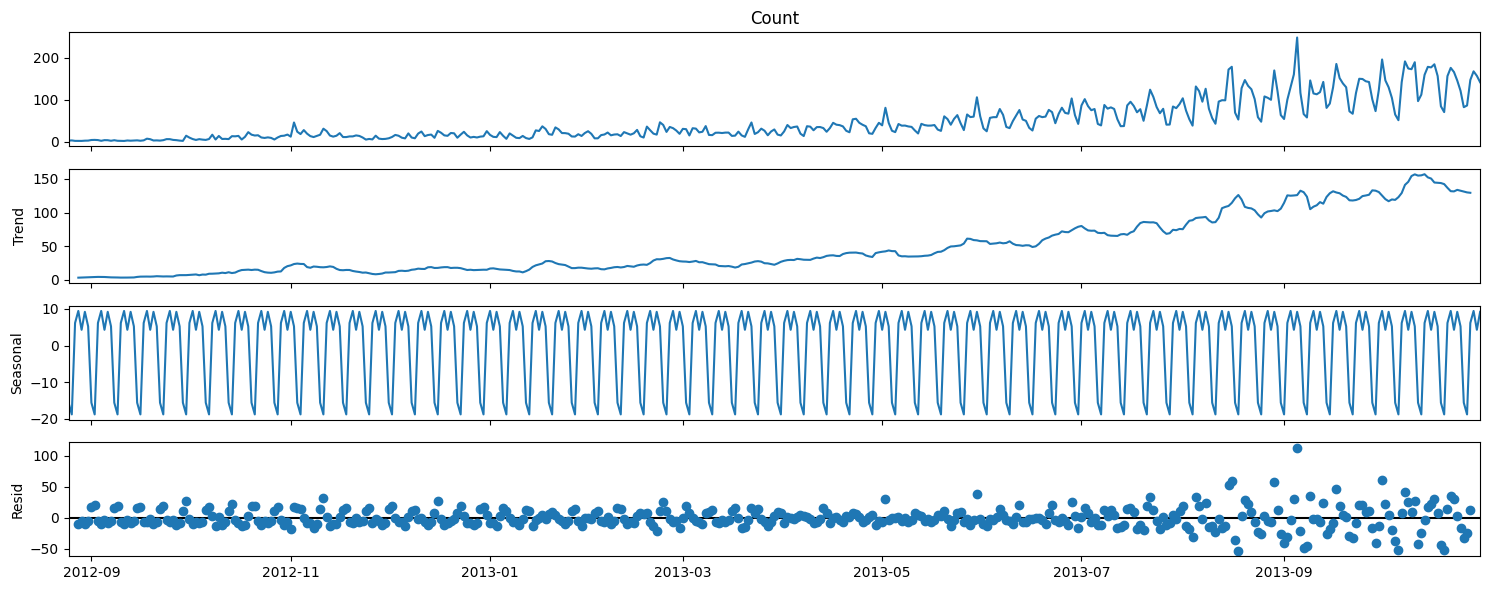

In [ ]:
import statsmodels.api as sm
sm.tsa.seasonal_decompose(train.Count).plot()
result = sm.tsa.stattools.adfuller(train.Count)
plt.show()

Holt extended simple exponential smoothing to allow forecasting of data with a trend. It is nothing more than exponential smoothing applied to both level(the average value in the series) and trend.

/usr/local/lib/python3.12/dist-packages/pandas/util/_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


<Figure size 1600x800 with 0 Axes>

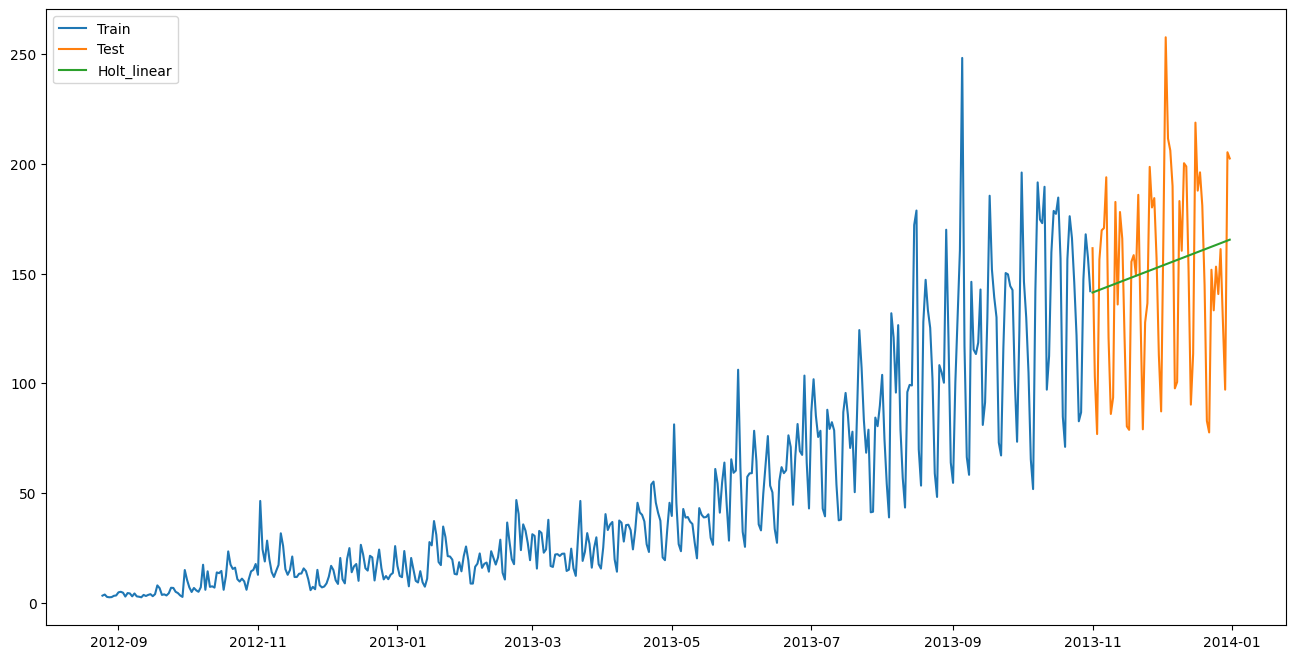

In [ ]:
y_hat_avg = test.copy()

fit1 = Holt(np.asarray(train['Count'])).fit(smoothing_level = 0.3,smoothing_slope = 0.1)
y_hat_avg['Holt_linear'] = fit1.forecast(len(test))

plt.figure(figsize=(16,8))
plt.plot(train['Count'], label='Train')
plt.plot(test['Count'], label='Test')
plt.plot(y_hat_avg['Holt_linear'], label='Holt_linear')
plt.legend(loc='best')
plt.show()

In [ ]:
rms = sqrt(mean_squared_error(test.Count, y_hat_avg.Holt_linear))
print(rms)

43.056259611507286


#Method 6 – Holt-Winters Method

Consider a hotel located on a hill station. It experiences high visits during the summer season whereas the visitors during the rest of the year are comparatively very less. Hence the profit earned by the owner will be far better in summer season than in any other season. This pattern will repeat itself every year. Such a repetition is called Seasonality. Datasets which show a similar set of pattern after fixed intervals of a time period suffer from seasonality.


<Figure size 1600x800 with 0 Axes>

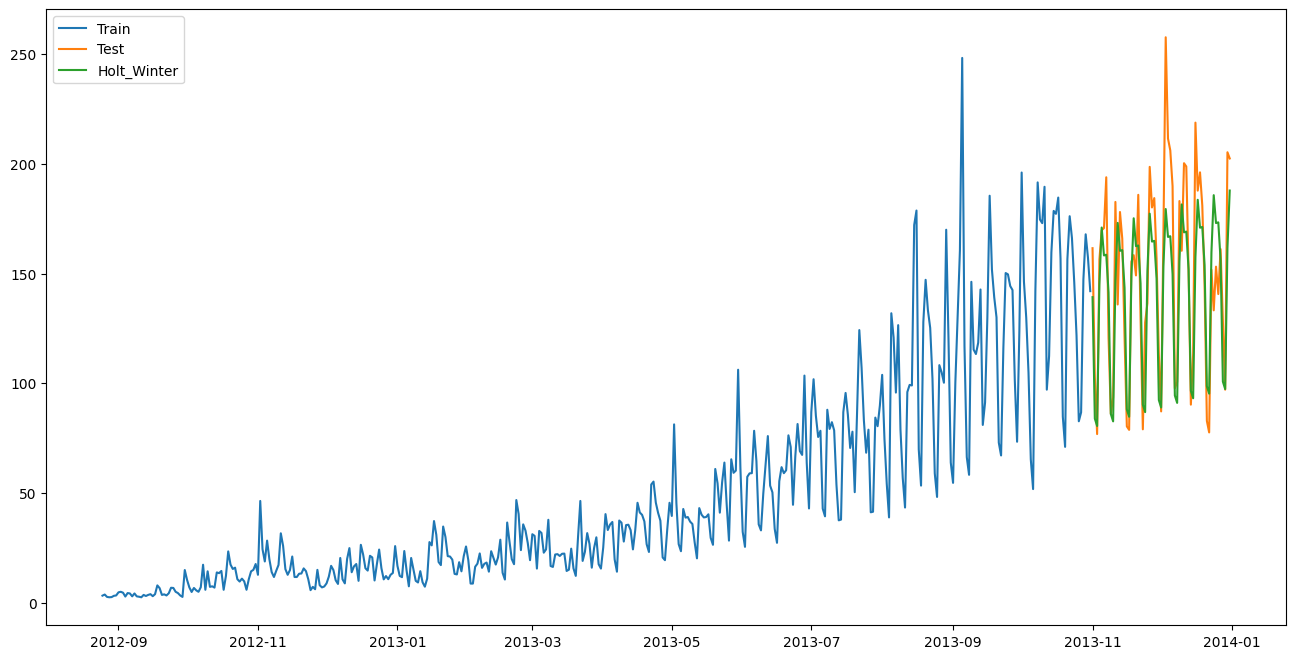

In [ ]:
y_hat_avg = test.copy()
fit1 = ExponentialSmoothing(np.asarray(train['Count']) ,seasonal_periods=7 ,trend='add', seasonal='add',).fit()
y_hat_avg['Holt_Winter'] = fit1.forecast(len(test))
plt.figure(figsize=(16,8))
plt.plot( train['Count'], label='Train')
plt.plot(test['Count'], label='Test')
plt.plot(y_hat_avg['Holt_Winter'], label='Holt_Winter')
plt.legend(loc='best')
plt.show()


In [ ]:
rms = sqrt(mean_squared_error(test.Count, y_hat_avg.Holt_Winter))
print(rms)

25.264842336699278


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<Figure size 1600x800 with 0 Axes>

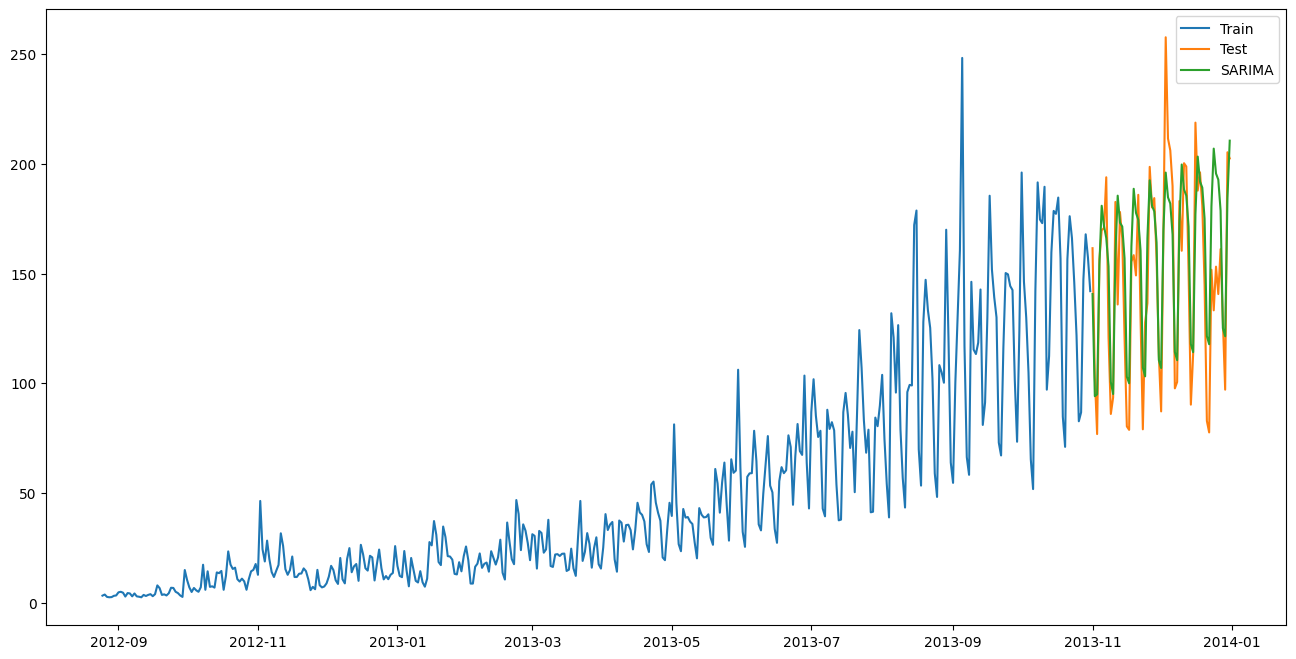

In [ ]:
#Method 7 – SARIMA
y_hat_avg = test.copy()
fit1 = sm.tsa.statespace.SARIMAX(train.Count, order=(2, 1, 4),seasonal_order=(0,1,1,7)).fit()
y_hat_avg['SARIMA'] = fit1.predict(start="2013-11-1", end="2013-12-31", dynamic=True)
plt.figure(figsize=(16,8))
plt.plot( train['Count'], label='Train')
plt.plot(test['Count'], label='Test')
plt.plot(y_hat_avg['SARIMA'], label='SARIMA')
plt.legend(loc='best')
plt.show()

In [ ]:
rms = sqrt(mean_squared_error(test.Count, y_hat_avg.SARIMA))
print(rms)

26.06283804259084
